In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
df= pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Loan-Credit-Analytics\dataset\loan_approval_dataset.csv")
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [9]:
X = df.drop(["loan_status", "loan_id"], axis=1)

# Clean target values
df["loan_status"] = df["loan_status"].astype(str).str.strip()
# Encode target
y = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

print(y.value_counts())
print("Missing target values:", y.isna().sum())

loan_status
1    2656
0    1613
Name: count, dtype: int64
Missing target values: 0


In [10]:
numerical_features = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

categorical_features = [
    "education",
    "self_employed"
]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (3415, 11)
Testing data : (854, 11)


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [13]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [14]:
lr_pred = logistic_model.predict(X_test)

lr_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:", lr_pred[:10])
print("Probabilities:", lr_probability[:10])

Predictions: [1 0 1 1 1 1 1 0 1 0]
Probabilities: [0.99091288 0.01612636 0.6026721  0.98104374 0.97759337 0.99936096
 0.99830696 0.36479886 0.82175131 0.07452412]


In [15]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_probability)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

cm_lr = confusion_matrix(y_test, lr_pred)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.9145
Precision: 0.921
Recall   : 0.9435
F1-Score : 0.9321
ROC-AUC  : 0.9726
Logistic Regression Confusion Matrix:
[[280  43]
 [ 30 501]]


### Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of 91.45% on the test dataset. The model obtained a precision of 92.10%, recall of 94.35%, and an F1-score of 93.21%.

The ROC-AUC score of 97.26% indicates strong discriminatory performance between approved and rejected loan applications.

The confusion matrix shows that the model correctly classified 280 rejected applications and 501 approved applications, while 43 rejected applications were incorrectly classified as approved and 30 approved applications were incorrectly classified as rejected.

Overall, Logistic Regression provides strong predictive performance on the test dataset.

In [16]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [17]:
rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions:", rf_pred[:10])
print("Probabilities:", rf_probability[:10])

Predictions: [1 0 0 1 1 1 1 0 1 0]
Probabilities: [0.93  0.015 0.055 0.965 1.    0.975 0.99  0.33  0.96  0.005]


In [18]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))
cm_rf = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Results
--------------------
Accuracy : 0.9813
Precision: 0.9849
Recall   : 0.9849
F1-Score : 0.9849
ROC-AUC  : 0.9986
Random Forest Confusion Matrix:
[[315   8]
 [  8 523]]


### Random Forest Evaluation

The Random Forest classifier achieved an accuracy of 98.13% on the test dataset. It obtained a precision, recall, and F1-score of 98.49%.

The ROC-AUC score of 99.86% indicates strong discrimination between approved and rejected loan applications.

The confusion matrix shows 315 correctly rejected applications and 523 correctly approved applications. The model incorrectly classified 8 rejected applications as approved and 8 approved applications as rejected.

The Random Forest model therefore demonstrated strong predictive performance on the test dataset.

In [19]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.914520,0.981265
1,Precision,0.920956,0.984934
2,Recall,0.943503,0.984934
3,F1-Score,0.932093,0.984934
4,ROC-AUC,0.972550,0.998636


In [20]:
# Get Random Forest classifier
rf_classifier = random_forest_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

# Show top 5 features
feature_importance.head(5)

,Feature,Importance
4,num__cibil_score,0.795536
3,num__loan_term,0.061487
2,num__loan_amount,0.030929
1,num__income_annum,0.019543
7,num__luxury_assets_value,0.019452


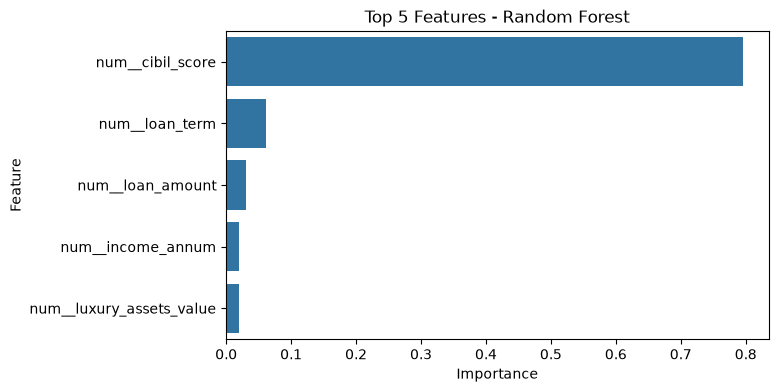

In [21]:
top_features = feature_importance.head(5)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Features - Random Forest")
plt.show()

### Feature Importance

The Random Forest model identifies CIBIL score as the most important feature for predicting loan approval, with an importance of approximately 79.55%. Loan term, loan amount, annual income, and luxury asset value have considerably lower individual importance.

The feature importance results are consistent with the EDA, where CIBIL score showed a strong relationship with loan approval.

In [23]:
import os

os.makedirs("models", exist_ok=True)
joblib.dump(
    random_forest_model,
    "models/loan_approval_random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [24]:
new_applicant = pd.DataFrame({
    "no_of_dependents": [2],
    "education": ["Graduate"],
    "self_employed": ["No"],
    "income_annum": [8000000],
    "loan_amount": [20000000],
    "loan_term": [10],
    "cibil_score": [750],
    "residential_assets_value": [10000000],
    "commercial_assets_value": [5000000],
    "luxury_assets_value": [15000000],
    "bank_asset_value": [7000000]
})
prediction = random_forest_model.predict(new_applicant)[0]

probability = random_forest_model.predict_proba(
    new_applicant
)[0][1]

if prediction == 1:
    result = "Approved"
else:
    result = "Rejected"

print("Loan Approval Prediction:", result)
print("Approval Probability:", round(probability * 100, 2), "%")

Loan Approval Prediction: Approved
Approval Probability: 97.5 %


### Example Loan Approval Prediction

The trained Random Forest model was tested on a new applicant. The model predicted the loan application as **Approved** with an estimated approval probability of **97.5%**.

This demonstrates the final prediction stage of the proposed Loan Approval Prediction System.